In [1]:
%%capture
%pip install qldpc
%pip install matplotlib

## Benchmarking a Knill quantum error correction cycle

This notebook showcases how various features in the `qldpc.circuits` module can be used to benchmark a Knill quantum error correction (QEC) cycle.

Knill QEC essentially just teleports the logical state of a code block onto a new code block.  The measurements performed for teleportation provide enough syndrome data to identify and correct physical errors.  The catch is that Knill QEC requires fault-tolerant circuits for preparing two code blocks whose logical states are maximally entangled with each other (for example, using fault-tolerant circuits to prepare logical |+> and |0> states, and a transversal CNOT).

### imports and plotting code

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import stim

from qldpc import circuits, codes, decoders
from qldpc.objects import Pauli

%matplotlib inline

In [3]:
def plot_error_and_discard_rates(
    error_rates: npt.NDArray[np.int_],
    logical_error_rates: npt.NDArray[np.int_],
    discard_rates: npt.NDArray[np.int_],
) -> tuple[plt.Figure, plt.Axes]:
    """Plot logical error rates and discard rates."""
    figure, axes = plt.subplots(1, 2, sharex=True, figsize=(7, 3))

    # logical error rates
    axes[0].plot(error_rates, logical_error_rates, marker="o", linestyle="-")
    axes[0].axline(
        (0, 0),
        slope=1,
        color="k",
        linestyle=":",
        label=r"$p_{\mathrm{log}}=p_{\mathrm{phys}}$",
    )
    axes[0].set_xlabel("physical error rate")
    axes[0].set_ylabel("logical error rate")

    # discard rates
    axes[1].plot(error_rates, discard_rates, marker="o", linestyle="-")
    axes[1].set_xlabel("physical error rate")
    axes[1].set_ylabel("discard rate")

    for axis in axes:
        axis.loglog()
        axis.grid(which="both")
    figure.tight_layout()
    return figure, axes

### Steane code

Build the code for which we wish to perform Knill QEC, and the necessary circuit primitives.

In [4]:
code = codes.SteaneCode()

# |0> state prep circuit
zero_prep_circuit = stim.Circuit("""
    # non-fault-tolerant state preparation
    H 0 2 4
    CX 0 3 2 1 4 5
    CX 0 1 2 6 4 3
    CX 2 5 3 6
    # flag errors in a logical Z representative
    H 7
    CZ 7 1 7 3 7 5
    MX 7
    DETECTOR rec[-1]  # post-selection flag
""")

# |+> state prep circuit
plus_prep_circuit = zero_prep_circuit.copy()
plus_prep_circuit.append("H", range(len(code)))

Initialize circuit metadata

In [5]:
# Identify the qubits used by each code block.
# The method circuits.QubitIDs.from_code(code) will automatically allocate len(code) data qubits
# and len(code.matrix) "check" qubits (one for each stabilizer).  You can additionally pass
# QubitIDs.from_code(code, num_anillas=...) to allocate more ancillas.
qubit_ids_0 = circuits.QubitIDs.from_code(code, num_ancillas=code.dimension)
qubit_ids_1 = qubit_ids_0.shifted(qubit_ids_0.max() + 1)
qubit_ids_2 = qubit_ids_1.shifted(qubit_ids_1.max() + 1)

# records to keep track of measurements and detectors in the circuit we build
meas_record = circuits.MeasurementRecord()
det_record = circuits.DetectorRecord()

Build a physical circuit to teleport code block 0 onto code block 2.

In order to identify the error rates of all logical observables (both X-type and Z-type), we initially entangle the logical qubits of code block 0 with _noiseless_ physical ancilla qubits.  This is essentially the same trick that we use to compute the logical error rates of all observables in `qldpc.circuits.get_memory_experiment`; see explanation [here](https://github.com/qLDPCOrg/qLDPC/blob/0834c26ea79061cc172fe466adceda06cb4a28b4/src/qldpc/circuits/memory.py#L79-L115).

In [6]:
# initialize empty circuit
circuit = stim.Circuit()

# prepare a logical Bell-pair state noiselessly on code block 0, and annotate its observables
circuit += circuits.get_logical_bell_prep(
    code,
    data_qubits=qubit_ids_0.data,
    ancilla_qubits=qubit_ids_0.ancilla,
)
circuit += circuits.get_observables(code, qubit_ids_0.data)

# prepare blocks 1 and 2 in a logical Bell state, and record flag detectors for post-selection
circuit += circuits.with_remapped_qubits(plus_prep_circuit, qubit_ids_1.all_qubits)
circuit += circuits.with_remapped_qubits(zero_prep_circuit, qubit_ids_2.all_qubits)
for cc, tt in zip(qubit_ids_1.data, qubit_ids_2.data):
    circuit.append("CX", [cc, tt])
det_record.append({"flags": range(circuit.num_detectors)})

# measure blocks 0 and 1 in the Bell basis, keeping a record of the measurements
for cc, tt in zip(qubit_ids_0.data, qubit_ids_1.data):
    circuit.append("CX", [cc, tt])
circuit.append("MX", qubit_ids_0.data)
meas_record.append({qubit: meas_index for meas_index, qubit in enumerate(qubit_ids_0.data)})
circuit.append("MZ", qubit_ids_1.data)
meas_record.append({qubit: meas_index for meas_index, qubit in enumerate(qubit_ids_1.data)})

# Annotate stabilizers (detectors) supported on the measurements of blocks 0 and 1,
# as well as the observables flipped by logical corrections from these measurement outcomes.
for data_qubits, basis in [
    (qubit_ids_0.data, Pauli.X),
    (qubit_ids_1.data, Pauli.Z),
]:
    # stabilizers
    for op_vec in code.get_stabilizer_ops(basis):
        support = [data_qubits[qubit] for qubit in range(len(code)) if op_vec[qubit]]
        target_recs = [meas_record.get_target_rec(qubit) for qubit in support]
        circuit.append("DETECTOR", target_recs)
    # observables
    for index, op_vec in enumerate(code.get_logical_ops(basis)):
        support = [data_qubits[qubit] for qubit in range(len(code)) if op_vec[qubit]]
        target_recs = [meas_record.get_target_rec(qubit) for qubit in support]
        # X-type observables are numbered from 0 to code.dimension-1, while
        # Z-type observables are numbered from code.dimension to 2*code.dimension-1.
        observable_index = index + code.dimension * int(basis)
        circuit.append("OBSERVABLE_INCLUDE", target_recs, [observable_index])

# append final (noiseless) stabilizer and observable readout
circuit += circuits.as_noiseless_circuit(
    circuits.get_pauli_product_measurements(code.get_stabilizer_ops(), qubit_ids_2.data)
)
for index in range(len(code.get_stabilizer_ops())):
    circuit.append("DETECTOR", [stim.target_rec(-index - 1)])
circuit += circuits.get_observables(code, qubit_ids_2.data)

Simulate the Knill QEC circuit with different error rates.  Use a simple depolarizing noise model and lookup table decoder.

In [7]:
error_rates = np.logspace(-4, -2, 5)
sinter_decoder = decoders.SinterDecoder(with_lookup=True, max_weight=3)

logical_error_rates = np.empty_like(error_rates)
discard_rates = np.empty_like(error_rates)

for pp, error_rate in enumerate(error_rates):
    print(pp, error_rate, end=" ")

    noise_model = circuits.DepolarizingNoiseModel(error_rate)
    noisy_circuit = noise_model.noisy_circuit(circuit)
    logical_error_rates[pp], discard_rates[pp] = circuits.get_logical_error_and_discard_rate(
        noisy_circuit,
        sinter_decoder,
        num_samples=10**6,
        post_select=det_record.get_events("flags"),
    )

    print(logical_error_rates[pp], discard_rates[pp])

0 0.0001 3.0043623341091266e-06 0.0014520000000000088
1 0.00031622776601683794 3.315799785980196e-05 0.004765000000000019
2 0.001 0.0003025601871405829 0.015071999999999974
3 0.0031622776601683794 0.002989180863790441 0.04622700000000002
4 0.01 0.026655821842524824 0.13568599999999997


Plot results!

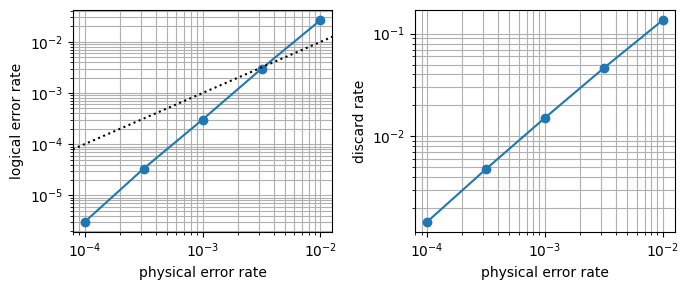

In [8]:
plot_error_and_discard_rates(error_rates, logical_error_rates, discard_rates)
plt.show()